# **Agenda**
- **PART 1 — Why SVM Matters**
- **PART 2 — Margin Optimization**
- **PART 3 — Mathematical Foundation**
- **PART 4 — Hard Margin vs Soft Margin**
- **PART 5 — C Parameter & Bias-Variance Tradeoff**
- **PART 6 — Kernel Methods**
- **PART 7 — Common Kernels**
- **PART 8 — Hyperparameter Tuning**
- **PART 9 — Feature Scaling**

https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html?utm_source=chatgpt.com

https://www.mlhive.com/playground/machine-learning/svm?utm_source=chatgpt.com

https://cnn-svm.vercel.app/svm?utm_source=chatgpt.com

https://www.mlvisualization.com/visualizations/support-vector-machines?utm_source=chatgpt.com

https://www.datacamp.com/tutorial/support-vector-regression-svr?utm_source=chatgpt.com

In [ ]:
KNN - Distance based -- Class + Regressio

Niave bayes - Probablity --> Classification

Linear / Logistic regrssion - linear family model

SVM - Support vector machine algorithm - linear family + distance based

factor of safety ? --> you are tasked with desigin activa --> 200kgs --> 240kgs ( what user will do ) --
unknow world you will alwasy have some factor of safelty

SVM - Classification + regression

instead of creating one line to divide two classes it will create a margin around your main line ( that is decision boundry)

Logistic regression
decision boundry --> A line that seperates two classes

SVM
Decision boundry + margin --> for both posiitve and negative classes

2D - two features - separate a class - line
3D - 3 features - separate a class - plane
ND - N Features - separate a class - Hyperplane

# **PART 1 — Why SVM Matters**

**What is SVM?**

- One-Line Definition (Must Memorize)

  - Support Vector Machine (SVM) is a margin-based classifier that finds the optimal separating hyperplane by maximizing the margin between classes.

**Core Philosophy**

- Most classifiers ask:

  - "Can I separate the classes?"

**SVM asks:**

- "Can I separate them with the largest possible safety margin?"

This difference is what gives SVM strong generalization capabilities.

**Why SVM Became Famous**

- Historically, SVMs were considered one of the most powerful classification algorithms before the deep learning era.

**They performed exceptionally well on:**

- Text Classification
- Bioinformatics
- Image Recognition
- Handwriting Recognition
- High-Dimensional Data


**Why SVM instead of Logistic Regression?**

- Expected Answer:
| SVM                           | Logistic Regression        |
| ----------------------------- | -------------------------- |
| Margin-based                  | Probability-based          |
| Uses support vectors          | Uses all points            |
| Strong theoretical guarantees | Simpler interpretation     |
| Effective in high dimensions  | Faster on massive datasets |


# **PART 2 — Margin Optimization**

**Hyperplane**

- In 2D:

  - Line

- In 3D:

  - Plane

- In n-dimensions:

  - Hyperplane

- General equation:

$$w^T
x+b=0$$

**Margin**

- Margin = Distance between the hyperplane and the nearest training points.

**Why Maximize Margin?**

- Larger margin means:

  - Better Generalization

Small changes in data do not affect predictions significantly.

**Robustness to Noise**

- Noise must travel farther before causing misclassification.

**Lower Variance**

- Model becomes less sensitive to training data fluctuations.

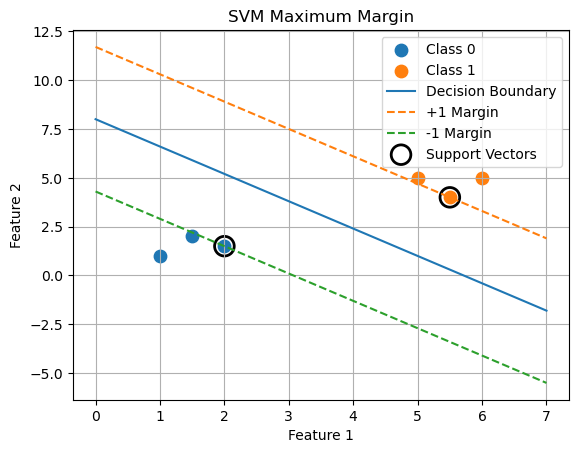

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Simple 2D dataset
X = np.array([
    [1, 1], [1.5, 2], [2, 1.5],
    [5, 5], [5.5, 4], [6, 5]
])

y = np.array([0, 0, 0, 1, 1, 1])

# Train linear SVM
model = SVC(kernel="linear", C=1)
model.fit(X, y)

# Get W and b
w = model.coef_[0]
b = model.intercept_[0]

# X-axis
xx = np.linspace(0, 7, 200)

# Decision boundary: WᵀX + b = 0
decision_boundary = -(w[0] * xx + b) / w[1]

# Margins: WᵀX + b = +1 and -1
margin_positive = -(w[0] * xx + b - 1) / w[1]
margin_negative = -(w[0] * xx + b + 1) / w[1]

# Plot classes
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    s=80
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    s=80
)

# Decision boundary
plt.plot(
    xx,
    decision_boundary,
    label="Decision Boundary"
)

# Margins
plt.plot(
    xx,
    margin_positive,
    "--",
    label="+1 Margin"
)

plt.plot(
    xx,
    margin_negative,
    "--",
    label="-1 Margin"
)

# Support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Maximum Margin")
plt.legend()
plt.grid(True)
plt.show()

# From Straight Line Equation to Hyperplane Equation

## 1. Start with the equation of a straight line

For a 2D line:

$$
y = mx + c
$$

Rearrange the equation:

$$
mx - y + c = 0
$$

Write $-y$ as $(-1)y$:

$$
mx + (-1)y + c = 0
$$

Now identify the coefficients:

$$
w_1 = m
$$

$$
w_2 = -1
$$

Therefore:

$$
w_1x + w_2y + c = 0
$$

> **Important:** We are not randomly assuming $w_1 = m$ and $w_2 = -1$.
> They are simply the coefficients of $x$ and $y$ after rearranging the line equation.

---

## 2. Represent the variables as vectors

The input variables $x$ and $y$ can be represented as a vector:

$$
X =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

The coefficients can also be represented as a vector:

$$
W =
\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}
$$

Our equation is currently:

$$
w_1x + w_2y + c = 0
$$

---

## 3. Recognize the dot product

The dot product of two vectors is:

$$
W \cdot X = w_1x + w_2y
$$

Therefore:

$$
w_1x + w_2y + c = 0
$$

can be written as:

$$
\boxed{W \cdot X + c = 0}
$$

This is the first important generalization.

---

## 4. Convert the dot product into matrix notation

Currently, $W$ is a column vector:

$$
W =
\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}
$$

Take its transpose:

$$
W^T =
\begin{bmatrix}
w_1 & w_2
\end{bmatrix}
$$

Now multiply:

$$
W^T X =
\begin{bmatrix}
w_1 & w_2
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

Matrix multiplication gives:

$$
W^T X = w_1x + w_2y
$$

But we already know:

$$
W \cdot X = w_1x + w_2y
$$

Therefore:

$$
\boxed{W \cdot X = W^T X}
$$

So our equation becomes:

$$
\boxed{W^T X + c = 0}
$$

---

# 5. Why is this a Hyperplane?

So far, we only have two features:

$$
X =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

Therefore:

$$
W^T X + c = 0
$$

represents a **line in 2D**.

Now suppose we have three features:

$$
X =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
$$

and:

$$
W =
\begin{bmatrix}
w_1 \\
w_2 \\
w_3
\end{bmatrix}
$$

Then:

$$
W^T X + c = 0
$$

becomes:

$$
w_1x_1 + w_2x_2 + w_3x_3 + c = 0
$$

This represents a **plane in 3D**.

If we have $n$ features:

$$
X =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
$$

then:

$$
\boxed{W^T X + c = 0}
$$

represents a **hyperplane in $n$-dimensional space**.

---

# Complete Journey

Starting from the ordinary straight-line equation:

$$
\boxed{y = mx + c}
$$

### Step 1 — Rearrange

$$
y = mx + c
$$

$$
\boxed{mx - y + c = 0}
$$

### Step 2 — Identify coefficients

$$
\boxed{w_1 = m,\qquad w_2 = -1}
$$

Therefore:

$$
\boxed{w_1x + w_2y + c = 0}
$$

### Step 3 — Recognize the dot product

$$
\boxed{W \cdot X + c = 0}
$$

### Step 4 — Convert dot product to matrix notation

$$
\boxed{W \cdot X = W^T X}
$$

Therefore:

$$
\boxed{W^T X + c = 0}
$$

---

## Final Understanding

The ordinary line equation:

$$
y = mx + c
$$

is simply the **2-dimensional special case** of the general hyperplane equation:

$$
\boxed{W^T X + c = 0}
$$

As the number of features increases:

- **2 features** → line in 2D
- **3 features** → plane in 3D
- **$n$ features** → hyperplane in $n$-dimensional space

This is the mathematical form of the **decision boundary used by SVM**.

# **PART 3 — Support Vectors**

**What are Support Vectors?**

- Support vectors are:

  - The training points closest to the decision boundary.

**S = Support Vector**



**Key Insight**

- Remove all other points:

  - Decision boundary barely changes.

- Remove support vectors:

  - Decision boundary changes dramatically.


**Interview Question**

**What determines the hyperplane?**

- Correct Answer:

  - Support vectors determine the hyperplane.

Not the entire dataset.

**Why This Matters**

- This makes SVM memory-efficient.

Only critical samples influence learning.

**Python Example**

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)

model = SVC(kernel="linear")
model.fit(X, y)

print("Number of Support Vectors:")
print(model.n_support_)

Number of Support Vectors:
[7 6]


In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Create dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=0
)

model = SVC(kernel="linear")
model.fit(X,y)

print(model.n_support_)

[15 14]


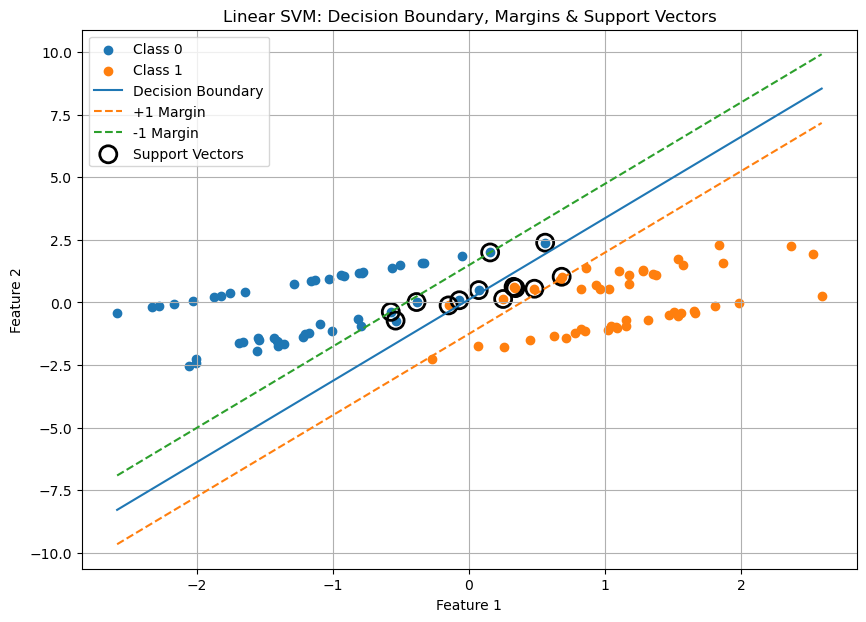

Number of Support Vectors:
[7 6]

Total Support Vectors:
13


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Create dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)

# Train SVM
model = SVC(kernel="linear")
model.fit(X, y)

# Get W and b
w = model.coef_[0]
b = model.intercept_[0]

# Create x-axis values
x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 300)

# Decision boundary: WᵀX + b = 0
decision_boundary = -(w[0] * x_values + b) / w[1]

# Margins: WᵀX + b = +1 and -1
margin_positive = -(w[0] * x_values + b - 1) / w[1]
margin_negative = -(w[0] * x_values + b + 1) / w[1]

# Plot all data points
plt.figure(figsize=(10, 7))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

# Decision boundary
plt.plot(
    x_values,
    decision_boundary,
    label="Decision Boundary"
)

# Margins
plt.plot(
    x_values,
    margin_positive,
    "--",
    label="+1 Margin"
)

plt.plot(
    x_values,
    margin_negative,
    "--",
    label="-1 Margin"
)

# Highlight support vectors
support_vectors = model.support_vectors_

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM: Decision Boundary, Margins & Support Vectors")

plt.legend()
plt.grid(True)
plt.show()

# Print number of support vectors
print("Number of Support Vectors:")
print(model.n_support_)

print("\nTotal Support Vectors:")
print(sum(model.n_support_))

# **PART 4 — Mathematical Foundation**

# SVM Optimization Objective

This is the **core mathematical idea behind SVM**.

The important thing is to understand **why maximizing the margin becomes minimizing $||w||^2$**.

---

# 1. What is SVM trying to achieve?

SVM wants to find a hyperplane:

$$
\boxed{w^T x + b = 0}
$$

that separates the two classes.

But there can be many separating hyperplanes.

For example:

```text
Class -1              Class +1

 ● ● ●                 ○ ○ ○
   ● ●               ○ ○
          \          /
           \        /
            \      /
             \    /
              \  /
````

SVM doesn't want just **any** separating line.

It wants the line with the **largest possible margin**.

The margin is the distance between the decision boundary and the closest points from each class.

---

# 2. Where do the equations $+1$ and $-1$ come from?

Our decision boundary is:

$$
w^T x + b = 0
$$

SVM defines two additional parallel boundaries:

$$
w^T x + b = +1
$$

and:

$$
w^T x + b = -1
$$

So visually:

```text
       Class +1

        ●   ●
-------------------   wᵀx + b = +1
       ↑
       │
       │  margin
       │
-------------------   wᵀx + b = 0
       Decision
       Boundary
       │
       │  margin
       ↓
-------------------   wᵀx + b = -1

        ●   ●

       Class -1
```

The points sitting on these two boundaries are the **support vectors**.

---

# 3. Why do we use $y_i$?

We assign labels:

$$
y_i =
\begin{cases}
+1 & \text{Class 1} \
-1 & \text{Class 2}
\end{cases}
$$

Our prediction function is:

$$
w^T x_i + b
$$

For a correctly classified point:

### Class +1

If:

$$
y_i = +1
$$

we want:

$$
w^T x_i + b \geq 1
$$

### Class -1

If:

$$
y_i = -1
$$

we want:

$$
w^T x_i + b \leq -1
$$

Both conditions can be combined into:

$$
\boxed{
y_i(w^T x_i + b) \geq 1
}
$$

Let's verify.

### For $y_i = +1$

$$
(+1)(w^T x_i + b) \geq 1
$$

Therefore:

$$
w^T x_i + b \geq 1
$$

### For $y_i = -1$

$$
(-1)(w^T x_i + b) \geq 1
$$

Therefore:

$$
w^T x_i + b \leq -1
$$

So one equation handles **both classes**.

---

# 4. Why minimize $||w||^2$?

This is where the margin comes in.

The distance between the two parallel hyperplanes:

$$
w^T x + b = 1
$$

and:

$$
w^T x + b = -1
$$

is:

$$
\boxed{
\text{Margin} = \frac{2}{||w||}
}
$$

Therefore:

$$
\text{Margin} = \frac{2}{||w||}
$$

Now look carefully.

If:

$$
||w|| \text{ is small}
$$

then:

$$
\frac{2}{||w||} \text{ is large}
$$

And if:

$$
||w|| \text{ is large}
$$

then:

$$
\frac{2}{||w||} \text{ is small}
$$

Therefore:

$$
\boxed{\text{Maximize Margin}}
$$

is equivalent to:

$$
\boxed{\text{Minimize } ||w||}
$$

Instead of minimizing $||w||$, we minimize its square:

$$
\boxed{
\frac{1}{2}||w||^2
}
$$

The $\frac{1}{2}$ is mainly for mathematical convenience because the derivative becomes simpler:

$$
\frac{d}{dw}
\left(
\frac{1}{2}\|w\|^2
\right)
= w
$$
=======

w
$$

---

# 5. Therefore the SVM Optimization Problem Becomes

We want:

$$
\boxed{
\min_{w,b}
\frac{1}{2}||w||^2
}
$$

subject to:

$$
\boxed{
y_i(w^T x_i + b) \geq 1
}
$$

This means:

### Objective

$$
\frac{1}{2}||w||^2
$$

**Keep $w$ as small as possible.**

### Constraint

$$
y_i(w^T x_i + b) \geq 1
$$

**Make sure every training point is correctly classified and outside the margin.**

So SVM is essentially saying:

> **Find the separating hyperplane with the smallest possible weight magnitude while still correctly separating all training points.**

And because smaller $||w||$ means larger margin, this gives us the **maximum-margin hyperplane**.

---

# 6. Derivation of the SVM Cost Function

Now let's derive where:

$$
\boxed{
\frac{1}{2}||w||^2
}
$$

comes from.

---

## Step 1 — Start with the Margin

We have two margin boundaries:

$$
w^T x + b = 1
$$

and:

$$
w^T x + b = -1
$$

The distance between them is:

$$
\boxed{
\text{Margin} = \frac{2}{||w||}
}
$$

---

## Step 2 — SVM Wants Maximum Margin

Therefore:

$$
\max \frac{2}{||w||}
$$

Since $2$ is a constant, maximizing this is equivalent to:

$$
\max \frac{1}{||w||}
$$

which is equivalent to:

$$
\min ||w||
$$

Therefore:

$$
\boxed{
\max \frac{2}{||w||}
\quad\Longleftrightarrow\quad
\min ||w||
}
$$

---

## Step 3 — Remove the Square Root

The norm is:

$$
||w|| = \sqrt{w^T w}
$$

Instead of minimizing:

$$
\sqrt{w^T w}
$$

we can minimize:

$$
w^T w = ||w||^2
$$

because squaring is a monotonically increasing operation for non-negative values.

Therefore:

$$
\boxed{
\min ||w||^2
}
$$

---

## Step 4 — Add $\frac{1}{2}$

We conventionally write:

$$
\boxed{
\min \frac{1}{2}||w||^2
}
$$

The $\frac{1}{2}$ doesn't change the optimal solution.

It simply makes differentiation easier:

$$
\frac{d}{dw}
\left(
\frac{1}{2}||w||^2
\right)
=======

w
$$

---

# Final Derivation

The whole reasoning can be remembered as:

$$
\boxed{
\text{Maximum Margin}
}
$$

$$
\Downarrow
$$

$$
\boxed{
\max \frac{2}{||w||}
}
$$

$$
\Downarrow
$$

$$
\boxed{
\min ||w||
}
$$

$$
\Downarrow
$$

$$
\boxed{
\min ||w||^2
}
$$

$$
\Downarrow
$$

$$
\boxed{
\min \frac{1}{2}||w||^2
}
$$

subject to:

$$
\boxed{
y_i(w^T x_i + b) \geq 1
}
$$

---

# Key Intuition

> **SVM minimizes $\frac{1}{2}||w||^2$ because the margin is $\frac{2}{||w||}$. Therefore, making the weights smaller automatically makes the margin larger.**

In simple terms:

$$
\boxed{
\text{Smaller } ||w||
\quad\Rightarrow\quad
\text{Larger Margin}
\quad\Rightarrow\quad
\text{Better Separation}
}
$$

```
```


In [ ]:
gard margin SVM
cost function = maximum margins (hard rule) - do anything but give me this

soft margin svm
regularization term - slack variable
cost function = max margin distance + penalise your model for misclassification

# **PART 5 — Hard Margin vs Soft Margin**

# Hard Margin SVM

## 1. What is Hard Margin SVM?

Hard Margin SVM assumes:

> **The data can be perfectly separated by a hyperplane.**

So we require every training point to satisfy:

$$
y_i(w^T x_i + b) \geq 1
$$

There are **no violations allowed**.

The idea is:

```text
Class -1                         Class +1

 ●  ●  ●                         ○  ○  ○
   ●  ●                       ○  ○
       ●                   ○
          |               |
----------|---------------|----------
       -1 margin       +1 margin
              |
         Decision Boundary

## 2. What is the Problem with Hard Margin?

Real-world data is rarely this clean.

Real datasets can contain:

* Noise
* Outliers
* Incorrect labels

For example:

```text
Class -1                    Class +1

 ● ● ●                       ○ ○ ○
 ● ●                    ○    ○
      ●
                ●  ← Outlier
                   ○
```

That one outlier might make the data impossible to perfectly separate.

Even if a separating line technically exists, the model may be forced to create a very strange boundary just to accommodate one outlier.

Therefore, Hard Margin SVM can be very sensitive to outliers.

---

# Soft Margin SVM

## 3. What is Soft Margin SVM?

Soft Margin SVM says:

> **"I'm willing to tolerate some mistakes if it gives me a much better overall boundary."**

Instead of requiring:

$$
y_i(w^T x_i + b) \geq 1
$$

without exception, we introduce a **slack variable**:

$$
\boxed{\xi_i}
$$

for every training point.

Think of $\xi_i$ as:

> **How much are we allowing this point to violate the ideal margin condition?**

---

# 4. Understanding the Slack Variable

The new constraint becomes:

$$
\boxed{
y_i(w^T x_i + b) \geq 1 - \xi_i
}
$$

Now let's see what different values of $\xi_i$ mean.

---

## Case 1: $\xi_i = 0$

Then:

$$
y_i(w^T x_i + b) \geq 1
$$

The point satisfies the margin perfectly.

**No violation.**

---

## Case 2: $0 < \xi_i < 1$

The point is correctly classified, but it is **inside the margin**.

For example:

$$
\xi_i = 0.5
$$

Then:

$$
y_i(w^T x_i + b) \geq 0.5
$$

So the point has violated the margin, but it is still on the correct side of the decision boundary.

This is a **margin violation**, but not a classification error.

---

## Case 3: $\xi_i = 1$

The point can be exactly on the decision boundary:

$$
y_i(w^T x_i + b) \geq 0
$$

---

## Case 4: $\xi_i > 1$

Now the point has crossed the decision boundary.

For example:

$$
\xi_i = 1.5
$$

means the point is **misclassified**.

Therefore:

$$
\boxed{
\xi_i > 1
\quad\Rightarrow\quad
\text{classification error}
}
$$

---

# 5. Why do we add $C\sum_i \xi_i$?

Our original Hard Margin objective was:

$$
\frac{1}{2}||w||^2
$$

which means:

> **Maximize the margin.**

But Soft Margin allows violations.

We therefore need to **penalize those violations**.

So we add:

$$
\boxed{
C\sum_i \xi_i
}
$$

The new objective becomes:

$$
\boxed{
\min_{w,b,\xi}
\left(
\frac{1}{2}||w||^2
+
C\sum_i \xi_i
\right)
}
$$

subject to:

$$
\boxed{
y_i(w^T x_i + b) \geq 1 - \xi_i
}
$$

and:

$$
\boxed{
\xi_i \geq 0
}
$$

---

# 6. What Does $C$ Do?

This is extremely important.

$C$ controls **how strongly SVM penalizes violations**.

## Large $C$

Violations become very expensive.

The model tries very hard to classify every training point correctly.

Therefore:

* Fewer violations
* Smaller training error
* Potentially smaller margin
* More sensitive to outliers

Think:

> **"I don't want mistakes."**

---

## Small $C$

Violations become less expensive.

The model is more willing to tolerate some points inside the margin or even misclassified.

Therefore:

* More violations allowed
* Wider margin
* Less sensitive to individual outliers
* Potentially better generalization

Think:

> **"I prefer a wider, more robust boundary even if a few points are wrong."**

---

# 7. The Real Meaning of the Soft Margin Objective

We now have:

$$
\frac{1}{2}||w||^2
+
C\sum_i \xi_i
$$

There are **two competing goals**.

### Goal 1 — Large Margin

$$
\frac{1}{2}||w||^2
$$

Minimizing this gives:

$$
\text{Larger Margin}
$$

### Goal 2 — Few Violations

$$
C\sum_i \xi_i
$$

Minimizing this gives:

$$
\text{Fewer Margin Violations and Errors}
$$

So SVM is balancing:

$$
\boxed{
\text{Large Margin}
\quad\text{vs.}\quad
\text{Few Mistakes}
}
$$

And $C$ controls that trade-off.

---

# 8. Hard Margin vs Soft Margin

| Hard Margin                      | Soft Margin                         |
| -------------------------------- | ----------------------------------- |
| Assumes perfectly separable data | Handles non-separable data          |
| No violations                    | Allows violations                   |
| No slack variables               | Uses $\xi_i$                        |
| Sensitive to outliers            | More robust to outliers             |
| Strict separation                | Trade-off between margin and errors |
| No $C$ penalty term              | Uses $C\sum_i \xi_i$                |

---

# 9. Easy Way to Remember

### Hard Margin

> **"Every point must obey the rules."**

$$
\boxed{
y_i(w^T x_i + b) \geq 1
}
$$

### Soft Margin

> **"Some points can break the rules, but breaking them costs something."**

$$
\boxed{
y_i(w^T x_i + b) \geq 1 - \xi_i
}
$$

The cost of those violations is:

$$
\boxed{
C\sum_i \xi_i
}
$$

---

# Final Soft Margin SVM Objective

The final Soft Margin SVM optimization problem is:

$$
\boxed{
\begin{aligned}
\min_{w,b,\xi}\quad
&
\frac{1}{2}||w||^2
+
C\sum_i \xi_i
[6pt]
\text{subject to}\quad
&
y_i(w^T x_i + b) \geq 1 - \xi_i
\
&
\xi_i \geq 0
\end{aligned}
}
$$

---

# Key Takeaway

## Soft Margin SVM
======================

$$
\boxed{
\text{Soft Margin SVM}
=
\text{Large Margin}
+
\text{Penalty for Violations}
}
$$

where:

$$
\boxed{
\frac{1}{2}||w||^2
}
$$

controls the **margin**, while:

$$
\boxed{
C\sum_i \xi_i
}
$$

controls the **penalty for violating the margin**.

Therefore:

$$
\boxed{
C
\text{ controls the trade-off between}
\text{margin size and classification errors.}
}
$$

```
```


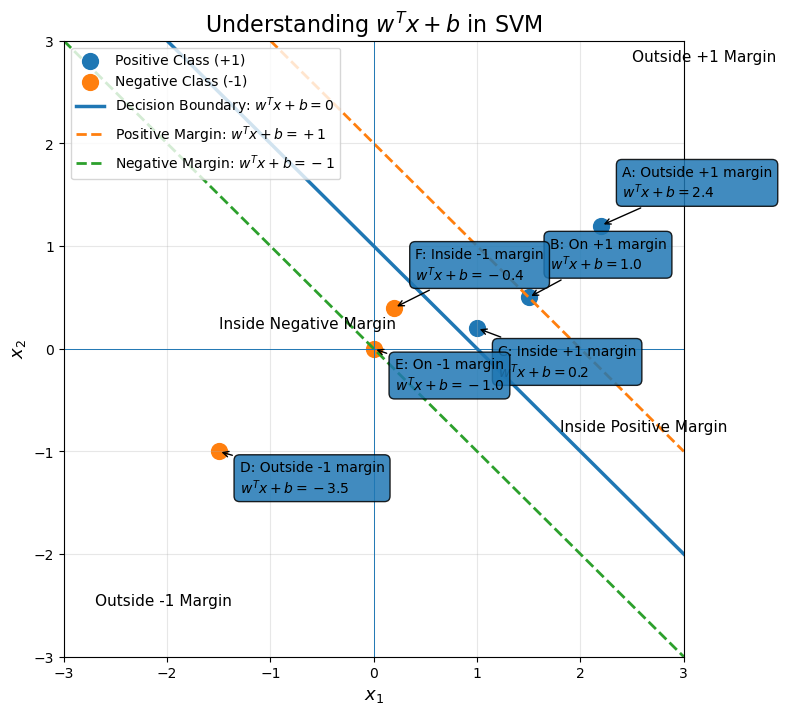


Point-wise SVM Scores
A: Outside +1 margin      -> w^T x + b = 2.4
B: On +1 margin           -> w^T x + b = 1.0
C: Inside +1 margin       -> w^T x + b = 0.2
D: Outside -1 margin      -> w^T x + b = -3.5
E: On -1 margin           -> w^T x + b = -1.0
F: Inside -1 margin       -> w^T x + b = -0.4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Define SVM hyperplane
#
# w^T x + b = 0
#
# w = [1, 1]
# b = -1
#
# Therefore:
# x1 + x2 - 1 = 0
# ---------------------------------------------------------

w = np.array([1, 1])
b = -1


# ---------------------------------------------------------
# 2. Create well-spaced teaching points
# ---------------------------------------------------------

points = np.array([
    [2.2, 1.2],    # A -> score = 2.4
    [1.5, 0.5],    # B -> score = 1.0
    [1.0, 0.2],    # C -> score = 0.2

    [-1.5, -1.0],  # D -> score = -3.5
    [0.0, 0.0],    # E -> score = -1.0
    [0.2, 0.4]     # F -> score = -0.4
])

labels = [
    "A: Outside +1 margin",
    "B: On +1 margin",
    "C: Inside +1 margin",
    "D: Outside -1 margin",
    "E: On -1 margin",
    "F: Inside -1 margin"
]


# ---------------------------------------------------------
# 3. Calculate w^T x + b
# ---------------------------------------------------------

scores = points @ w + b


# ---------------------------------------------------------
# 4. Create plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 8))


# Positive class
plt.scatter(
    points[:3, 0],
    points[:3, 1],
    s=130,
    label="Positive Class (+1)"
)


# Negative class
plt.scatter(
    points[3:, 0],
    points[3:, 1],
    s=130,
    label="Negative Class (-1)"
)


# ---------------------------------------------------------
# 5. Create SVM lines
# ---------------------------------------------------------

x = np.linspace(-3, 3, 400)


# Decision boundary:
# x1 + x2 - 1 = 0
decision_boundary = 1 - x


# Positive margin:
# x1 + x2 - 1 = +1
positive_margin = 2 - x


# Negative margin:
# x1 + x2 - 1 = -1
negative_margin = -x


# Plot decision boundary
plt.plot(
    x,
    decision_boundary,
    linewidth=2.5,
    label=r"Decision Boundary: $w^Tx+b=0$"
)


# Plot +1 margin
plt.plot(
    x,
    positive_margin,
    "--",
    linewidth=2,
    label=r"Positive Margin: $w^Tx+b=+1$"
)


# Plot -1 margin
plt.plot(
    x,
    negative_margin,
    "--",
    linewidth=2,
    label=r"Negative Margin: $w^Tx+b=-1$"
)


# ---------------------------------------------------------
# 6. Add clearly separated labels
# ---------------------------------------------------------

label_offsets = [
    (15, 20),    # A
    (15, 20),    # B
    (15, -35),   # C
    (15, -30),   # D
    (15, -30),   # E
    (15, 20)     # F
]


for i, (point, score) in enumerate(zip(points, scores)):

    plt.annotate(
        f"{labels[i]}\n"
        f"$w^Tx+b={score:.1f}$",

        xy=(point[0], point[1]),

        xytext=label_offsets[i],
        textcoords="offset points",

        fontsize=10,

        bbox=dict(
            boxstyle="round,pad=0.4",
            alpha=0.85
        ),

        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3"
        )
    )


# ---------------------------------------------------------
# 7. Add region labels
# ---------------------------------------------------------

plt.text(
    2.5,
    2.8,
    "Outside +1 Margin",
    fontsize=11
)

plt.text(
    1.8,
    -0.8,
    "Inside Positive Margin",
    fontsize=11
)

plt.text(
    -2.7,
    -2.5,
    "Outside -1 Margin",
    fontsize=11
)

plt.text(
    -1.5,
    0.2,
    "Inside Negative Margin",
    fontsize=11
)


# ---------------------------------------------------------
# 8. Formatting
# ---------------------------------------------------------

plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.xlabel(r"$x_1$", fontsize=13)
plt.ylabel(r"$x_2$", fontsize=13)

plt.title(
    r"Understanding $w^Tx+b$ in SVM",
    fontsize=16
)

plt.axhline(0, linewidth=0.7)
plt.axvline(0, linewidth=0.7)

plt.grid(True, alpha=0.3)

plt.legend(
    loc="upper left",
    fontsize=10
)

plt.show()


# ---------------------------------------------------------
# 9. Print calculations
# ---------------------------------------------------------

print("\nPoint-wise SVM Scores")
print("=" * 55)

for i, (point, score) in enumerate(zip(points, scores)):

    print(
        f"{labels[i]:25s} "
        f"-> w^T x + b = {score:.1f}"
    )

# Understanding the Slack Variable and Penalty

> **The slack variable $\xi_i$ is NOT the value of $w^T x_i+b$.**

Instead, $\xi_i$ is calculated **from the SVM score** $w^T x_i+b$.

The formula is:

$$
\boxed{
\xi_i =
\max\left(
0,\;
1-y_i(w^T x_i+b)
\right)
}
$$

---

# Example

Suppose we have 5 training points.

| Point | True Class $y_i$ | SVM Score $w^T x_i+b$ |
|---|---:|---:|
| A | $+1$ | $2$ |
| B | $+1$ | $0.5$ |
| C | $+1$ | $-0.5$ |
| D | $-1$ | $-2$ |
| E | $-1$ | $-0.5$ |

Remember:

$$
\boxed{
\text{SVM Score}=w^T x_i+b
}
$$

Now calculate the slack for each point.

---

## Point A

$$
y_i=+1
$$

$$
w^T x_i+b=2
$$

Therefore:

$$
\xi_A
=
\max\left(
0,\;
1-(+1)(2)
\right)
$$

$$
=
\max(0,-1)
$$

$$
\boxed{\xi_A=0}
$$

So there is **no penalty**.

The point is correctly classified and outside the margin.

---

## Point B

$$
y_i=+1
$$

$$
w^T x_i+b=0.5
$$

Therefore:

$$
\xi_B
=
\max\left(
0,\;
1-(+1)(0.5)
\right)
$$

$$
=
\max(0,0.5)
$$

$$
\boxed{\xi_B=0.5}
$$

This point is **correctly classified but inside the margin**.

Therefore, it receives a penalty of $0.5$.

---

## Point C

$$
y_i=+1
$$

$$
w^T x_i+b=-0.5
$$

Therefore:

$$
\xi_C
=
\max\left(
0,\;
1-(+1)(-0.5)
\right)
$$

$$
=
\max(0,1.5)
$$

$$
\boxed{\xi_C=1.5}
$$

This point is **misclassified**, because its score is negative even though its true class is $+1$.

---

## Point D

$$
y_i=-1
$$

$$
w^T x_i+b=-2
$$

Therefore:

$$
\xi_D
=
\max\left(
0,\;
1-(-1)(-2)
\right)
$$

$$
=
\max(0,-1)
$$

$$
\boxed{\xi_D=0}
$$

This point is correctly classified and outside the margin.

---

## Point E

$$
y_i=-1
$$

$$
w^T x_i+b=-0.5
$$

Therefore:

$$
\xi_E
=
\max\left(
0,\;
1-(-1)(-0.5)
\right)
$$

$$
=
\max(0,0.5)
$$

$$
\boxed{\xi_E=0.5}
$$

This point is correctly classified but **inside the negative margin**.

---

# Total Slack / Total Violation

We have:

$$
\xi_A=0
$$

$$
\xi_B=0.5
$$

$$
\xi_C=1.5
$$

$$
\xi_D=0
$$

$$
\xi_E=0.5
$$

Therefore:

$$
\sum_i \xi_i
=
0+0.5+1.5+0+0.5
$$

$$
\boxed{
\sum_i \xi_i=2.5
}
$$

---

# Applying $C$

Suppose:

$$
C=10
$$

Then the violation penalty is:

$$
C\sum_i\xi_i
=
10(2.5)
$$

Therefore:

$$
\boxed{
C\sum_i\xi_i=25
}
$$

So the complete Soft-Margin SVM objective would be:

$$
\boxed{
\frac{1}{2}\|w\|^2+25
}
$$

---

# The Complete Process

The process can be remembered as:

### Step 1 — Calculate the SVM score

$$
\boxed{
w^T x_i+b
}
$$

↓

### Step 2 — Take the actual class into account

$$
\boxed{
y_i(w^T x_i+b)
}
$$

↓

### Step 3 — Calculate the slack

$$
\boxed{
\xi_i=
\max\left(
0,\;
1-y_i(w^T x_i+b)
\right)
}
$$

↓

### Step 4 — Add all slack values

$$
\boxed{
\sum_i\xi_i
}
$$

↓

### Step 5 — Apply the penalty parameter $C$

$$
\boxed{
C\sum_i\xi_i
}
$$

---

# Key Point

The score:

$$
w^T x_i+b
$$

does **not** itself become the slack variable.

Instead:

$$
\boxed{
w^T x_i+b
\rightarrow
y_i(w^T x_i+b)
\rightarrow
\xi_i
}
$$

For points that satisfy the margin, the value inside the $\max$ becomes negative, so:

$$
\boxed{\xi_i=0}
$$

Only points that **violate the margin** contribute to:

$$
\boxed{
C\sum_i\xi_i
}
$$

Therefore, the model balances:

$$
\boxed{
\text{Large Margin}
+
\text{Low Violation Penalty}
}
$$

# **PART 6 — C Parameter**

### What is (C)?

Think of **(C) as the strictness control** of SVM.

It controls how much the model **penalizes margin violations and misclassification**.

### Small (C)

SVM is **more tolerant** of mistakes.

* Allows more points inside the margin or misclassified
* Tries to keep the **margin large**
* Usually gives **higher bias and lower variance**
* Can generalize better when data contains noise

Think:

> **"I care more about a wide, stable margin than perfect training accuracy."**

### Large (C)

SVM is **stricter** about mistakes.

* Strongly penalizes violations
* Tries to classify training points correctly
* Often produces a **narrower margin**
* Gives **lower bias and higher variance**
* Can increase the risk of overfitting

Think:

> **"I care more about fitting the training data correctly."**

### Easy way to remember

$$
\boxed{
\text{Small } C
\;\rightarrow\;
\text{Wide Margin + More Errors}
}
$$

$$
\boxed{
\text{Large } C
\;\rightarrow\;
\text{Narrow Margin + Fewer Errors}
}
$$

| (C)    | Main Effect                    |
| ------ | ------------------------------ |
| Small  | Wide margin                    |
| Medium | Balance                        |
| Large  | Fewer errors, overfitting risk |


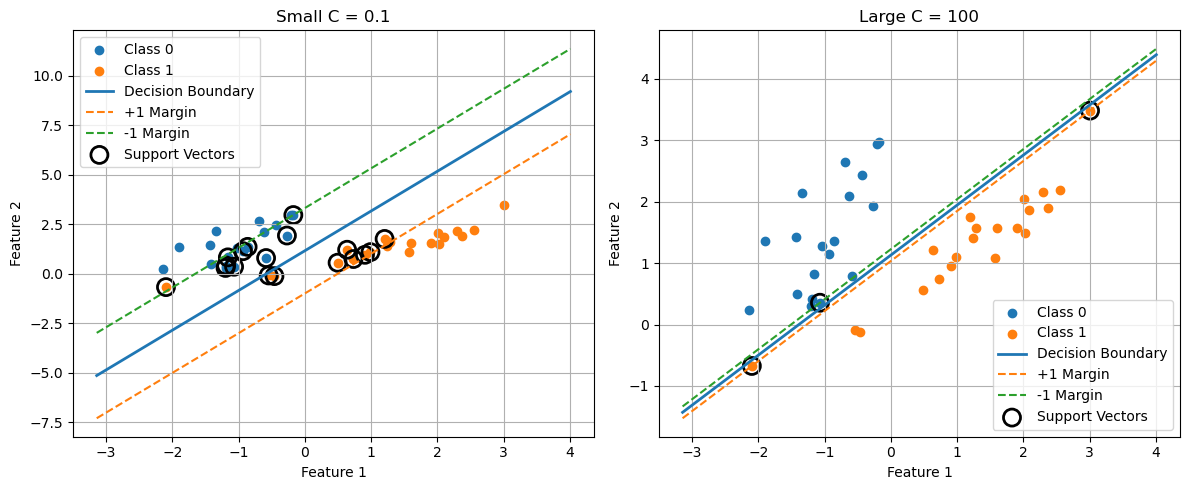

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# --------------------------------------------------
# 1. Create a simple dataset
# --------------------------------------------------

X, y = make_classification(
    n_samples=40,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

# --------------------------------------------------
# 2. Train two SVM models
# --------------------------------------------------

# Small C -> more tolerant of mistakes
svm_small_c = SVC(kernel="linear", C=0.1)
svm_small_c.fit(X, y)

# Large C -> stricter about mistakes
svm_large_c = SVC(kernel="linear", C=100)
svm_large_c.fit(X, y)


# --------------------------------------------------
# 3. Function to calculate decision boundary
# --------------------------------------------------

def plot_boundary(model, X, y, title):

    # Get weights and bias
    w = model.coef_[0]
    b = model.intercept_[0]

    # Create x-axis values
    x_values = np.linspace(
        X[:, 0].min() - 1,
        X[:, 0].max() + 1,
        200
    )

    # Decision boundary:
    # w1*x + w2*y + b = 0
    decision_boundary = -(w[0] * x_values + b) / w[1]

    # Margins:
    # w1*x + w2*y + b = +1
    margin_positive = -(w[0] * x_values + b - 1) / w[1]

    # w1*x + w2*y + b = -1
    margin_negative = -(w[0] * x_values + b + 1) / w[1]

    # Plot data
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0"
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1"
    )

    # Decision boundary
    plt.plot(
        x_values,
        decision_boundary,
        linewidth=2,
        label="Decision Boundary"
    )

    # Margins
    plt.plot(
        x_values,
        margin_positive,
        "--",
        label="+1 Margin"
    )

    plt.plot(
        x_values,
        margin_negative,
        "--",
        label="-1 Margin"
    )

    # Support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Support Vectors"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)


# --------------------------------------------------
# 4. Plot Small C
# --------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plot_boundary(
    svm_small_c,
    X,
    y,
    "Small C = 0.1"
)


# --------------------------------------------------
# 5. Plot Large C
# --------------------------------------------------

plt.subplot(1, 2, 2)

plot_boundary(
    svm_large_c,
    X,
    y,
    "Large C = 100"
)

plt.tight_layout()
plt.show()

In [ ]:
Polynomial features

Original dataset - X1, x2
degree = 2
polynominal data - X1^2, X2^2, X1*X2

Final dataset - X1, x2, X1^2, X2^2, X1*X2

Model.fit(final_dataset)

Better accuracy >>> than before

Linear --> Polynomial kernel

Data from 2D --> higher Dimernsions

On top of that your model.fit(higher dimension data)

model = SVC(kernels="polynomial")
model.fit(orginial dataset)

finally you will get polynomial model

# **PART 7 — Kernel Methods**

# Why Kernels Exist

The key idea is that **kernels solve the problem when a straight line cannot separate the classes**.

---

## 1. Why do Kernels Exist?

Consider an XOR-like dataset:

```text
Class 1       Class 0

●             ○

○             ●
````

No single straight line can separate the two classes.

Therefore:

$$
\boxed{
\text{Linear SVM fails}
}
$$

---

## 2. Transform the Data

Instead of trying to find a complicated boundary in the original 2D space, we **transform the data into a higher-dimensional space**.

Suppose our original features are:

$$
x =
\begin{bmatrix}
x_1 \
x_2
\end{bmatrix}
$$

We could create a new feature:

$$
x_3 = x_1x_2
$$

Now the data is represented using:

$$
\phi(x) =
\begin{bmatrix}
x_1 \
x_2 \
x_1x_2
\end{bmatrix}
$$

So we have gone from:

$$
\boxed{
\text{2D} \rightarrow \text{3D}
}
$$

In this new space, the previously non-linearly separable data may become **linearly separable**.

Conceptually:

```text
Original Space          Higher-Dimensional Space

    ○  ●                       ●
    ●  ○                  ─────────
                           ○     ○
```

The important point is:

> **A nonlinear boundary in the original space can become a linear boundary in a higher-dimensional space.**

---

## 3. The Problem with Explicitly Transforming Data

Suppose we have thousands of features and transform them into a very high-dimensional space.

Computing:

$$
\phi(x)
$$

explicitly can become extremely expensive.

For example:

$$
x \rightarrow \phi(x)
$$

where $\phi(x)$ creates **millions of features**.

We don't really want to calculate and store all of them.

---

## 4. Enter the Kernel Trick

Here's the clever part.

SVM relies heavily on **dot products** between data points:

$$
\phi(x_i)^T\phi(x_j)
$$

Instead of calculating:

$$
\phi(x_i)
$$

and:

$$
\phi(x_j)
$$

explicitly and then taking their dot product, a **kernel function** calculates the result directly:

$$
\boxed{
K(x_i, x_j)
=
\phi(x_i)^T \phi(x_j)
}
$$

So the kernel gives us the **inner product in the transformed space without explicitly creating that space**.

That's the **Kernel Trick**.

---

## 5. Simple Intuition

### Without Kernel Trick

```text
X
 ↓
Transform X → φ(X)
 ↓
Huge feature space
 ↓
Calculate dot product
```

### With Kernel Trick

```text
X₁ ──────┐
         ├──→ Kernel → Inner Product
X₂ ──────┘
```

We get the same mathematical result without explicitly constructing the high-dimensional features.

---

## Key Takeaway

> **The Kernel Trick allows SVM to work as if the data were transformed into a higher-dimensional space, without explicitly calculating that transformation.**

The basic idea is:

$$
\boxed{
\text{Original Space}
\rightarrow
\text{Higher-Dimensional Space}
\rightarrow
\text{Linear Separation}
}
$$

while the Kernel Trick avoids explicitly constructing that higher-dimensional space.

```
```


# PART 8 — Common Kernels

# 1. Linear Kernel

The linear kernel is simply the **dot product** between two data points:

$$
\boxed{
K(x_i, x_j) = x_i^T x_j
}
$$

It is basically saying:

> **"How similar are these two points based on their original features?"**

Because there is **no feature transformation**, the resulting decision boundary is linear.

### When to use it?

It works especially well for:

- **Text classification** → text data usually has thousands of sparse features.
- **High-dimensional sparse data** → many features but most values are zero.
- **Large datasets** → computationally simpler than nonlinear kernels.

---

# 2. Polynomial Kernel

The polynomial kernel is:

$$
\boxed{
K(x_i, x_j) = (x_i^T x_j + c)^d
}
$$

where:

- $c$ → controls the influence of lower-order terms.
- $d$ → degree of the polynomial.

It allows SVM to capture **nonlinear relationships**.

---

## Intuition

Suppose:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

With a polynomial kernel of degree $2$, the model can effectively work with terms such as:

$$
x_1^2
$$

$$
x_2^2
$$

$$
x_1x_2
$$

These are **feature interactions and nonlinear terms**.

The important part is that you don't have to manually create these new features.

For example, instead of manually creating:

$$
\begin{bmatrix}
x_1 \\
x_2 \\
x_1^2 \\
x_2^2 \\
x_1x_2
\end{bmatrix}
$$

the polynomial kernel handles the computation implicitly.

### When to use it?

Use the polynomial kernel when:

> **Feature interactions are important and you expect nonlinear relationships between features.**

In [ ]:
kernerls

polynomical
Radial basis Function -

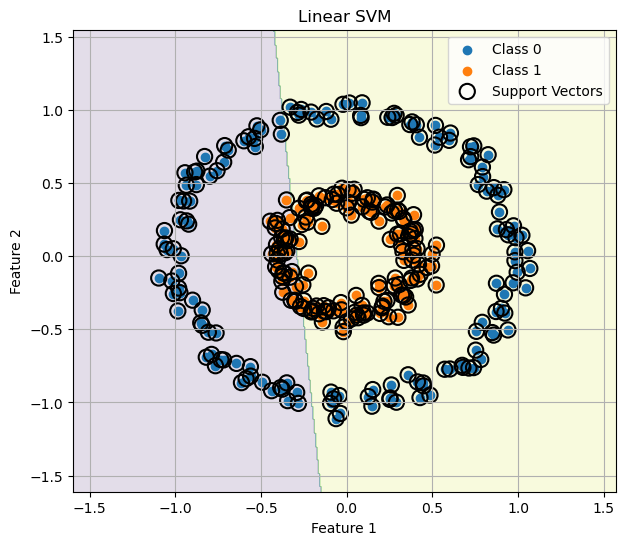

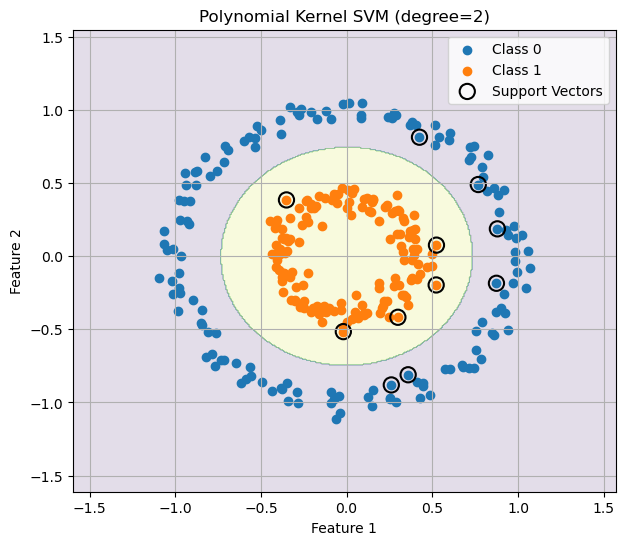

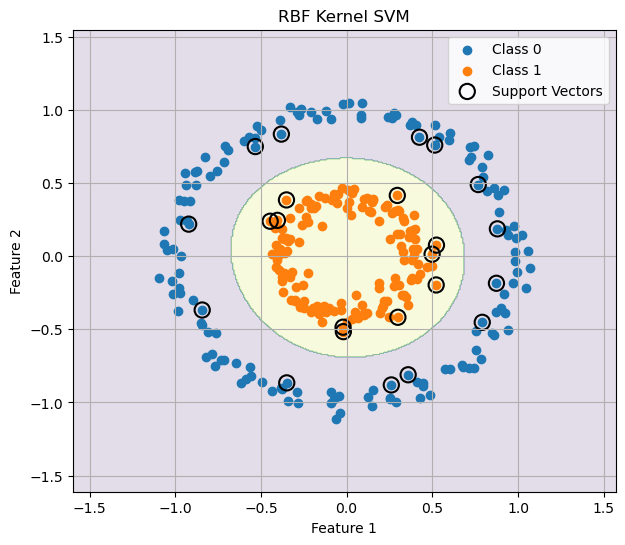

In [ ]:
# If Plotly is not installed, run this once:
# !pip install plotly

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.datasets import make_circles
from sklearn.svm import SVC


# ============================================================
# 1. Create radial / concentric-circle data
# ============================================================

X, y = make_circles(
    n_samples=300,
    factor=0.4,
    noise=0.05,
    random_state=42
)


# ============================================================
# 2. Train three SVM models
# ============================================================

# Linear SVM
linear_svm = SVC(kernel="linear", C=1)
linear_svm.fit(X, y)

# Polynomial Kernel SVM
poly_svm = SVC(
    kernel="poly",
    degree=2,
    C=1,
    gamma="scale"
)
poly_svm.fit(X, y)

# RBF Kernel SVM (Radial basis Function)
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)
rbf_svm.fit(X, y)


# ============================================================
# 3. Function to plot 2D decision boundary
# ============================================================

def plot_decision_boundary(model, X, y, title):

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.15
    )

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0"
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1"
    )

    # Highlight support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Support Vectors"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.show()


# ============================================================
# 4. Visualize Linear SVM
# ============================================================

plot_decision_boundary(
    linear_svm,
    X,
    y,
    "Linear SVM"
)


# ============================================================
# 5. Visualize Polynomial Kernel
# ============================================================

plot_decision_boundary(
    poly_svm,
    X,
    y,
    "Polynomial Kernel SVM (degree=2)"
)


# ============================================================
# 6. Visualize RBF Kernel
# ============================================================

plot_decision_boundary(
    rbf_svm,
    X,
    y,
    "RBF Kernel SVM"
)


# ============================================================
# 7. Explicitly create a 3D feature space
#
#    z = x1² + x2²
#
#    This is the radial feature.
# ============================================================

x1 = X[:, 0]
x2 = X[:, 1]

z = x1**2 + x2**2


# ============================================================
# 8. Create an interactive 3D visualization
# ============================================================

fig = go.Figure()


# Class 0
fig.add_trace(
    go.Scatter3d(
        x=x1[y == 0],
        y=x2[y == 0],
        z=z[y == 0],
        mode="markers",
        name="Class 0",
        marker=dict(
            size=5
        )
    )
)


# Class 1
fig.add_trace(
    go.Scatter3d(
        x=x1[y == 1],
        y=x2[y == 1],
        z=z[y == 1],
        mode="markers",
        name="Class 1",
        marker=dict(
            size=5
        )
    )
)


# ============================================================
# 9. Create a separating plane
#
# In transformed space:
#
#       z = approximately constant
#
# The plane separates the inner circle from the outer circle.
# ============================================================

z_min = z.min()
z_max = z.max()

# Estimate a separating level between the two classes
z_class_0_mean = z[y == 0].mean()
z_class_1_mean = z[y == 1].mean()

z_plane = (z_class_0_mean + z_class_1_mean) / 2


plane_x = np.linspace(
    x1.min(),
    x1.max(),
    30
)

plane_y = np.linspace(
    x2.min(),
    x2.max(),
    30
)

plane_x, plane_y = np.meshgrid(
    plane_x,
    plane_y
)

plane_z = np.full_like(
    plane_x,
    z_plane
)


# Add separating plane
fig.add_trace(
    go.Surface(
        x=plane_x,
        y=plane_y,
        z=plane_z,
        opacity=0.5,
        name="Separating Plane",
        showscale=False
    )
)


# ============================================================
# 10. Final 3D plot settings
# ============================================================

fig.update_layout(
    title="Polynomial Feature Transformation: 2D → 3D",
    scene=dict(
        xaxis_title="x₁",
        yaxis_title="x₂",
        zaxis_title="z = x₁² + x₂²"
    ),
    width=900,
    height=700
)

fig.show()

# **PART 9 — Hyperparameter Tuning**

## Key Hyperparameters

| Parameter  | Meaning                                          |
| ---------- | ------------------------------------------------ |
| **C**      | Regularization / penalty for violations          |
| **Gamma**  | How far a training point influences the boundary |
| **Kernel** | Shape of the decision boundary                   |

### Gamma Intuition

Think of **Gamma** as the **reach or influence of each training point**.

### Low Gamma

Each point influences a **larger area**.

* Broad influence
* Smooth decision boundary
* Simpler model
* Better generalization

Think:

> **"Look at the bigger picture."**

### High Gamma

Each point influences only a **small local area**.

* Very local influence
* Complex decision boundary
* Captures fine details
* Higher risk of overfitting

Think:

> **"Pay attention to every small detail."**

### Easy way to remember

$$
\boxed{
\text{Low Gamma}
\rightarrow
\text{Smooth Boundary}
}
$$

$$
\boxed{
\text{High Gamma}
\rightarrow
\text{Complex Boundary}
}
$$

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVC(),
    params,
    cv=5
)

grid.fit(X, y)

print(grid.best_params_)

{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = {
    "C":[0.1,1,10,100],
    "gamma":[0.001,0.01, 0.1,1],
    "kernel":["poly","rbf"]
}

# SCV_model = SVC()

grid = GridSearchCV(SVC(),params, cv=5)

grid.fit(X,y)

print(grid.best_estimator_)
print(grid.best_params_)

SVC(C=1, gamma=0.1)
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


# **PART 10 — Feature Scaling & Interview Perspective**

**Why Scaling Matters**

- SVM is fundamentally:

  - A Distance-Based Optimization Algorithm

**Distance affects:**

 - Margins
 - Support vectors
 - Kernel computations
 - Problem Without Scaling

**Dataset:**
| Age | Salary |
| --- | ------ |
| 25  | 50000  |
| 30  | 80000  |


Salary dominates.

Model ignores Age.

**Consequences**
- Distorted margins
- Poor kernels
- Unstable optimization


**Solution**
- Feature Standardization


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1,
        gamma="scale"
    ))
])

pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=1))])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline = Pipeline( [
    ("scaler", StandardScaler()),
    ("svm",SVC(kernel="rbf", C=1, gamma="scale"))])

pipeline.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=1))])

Dataset shape: (500, 2)


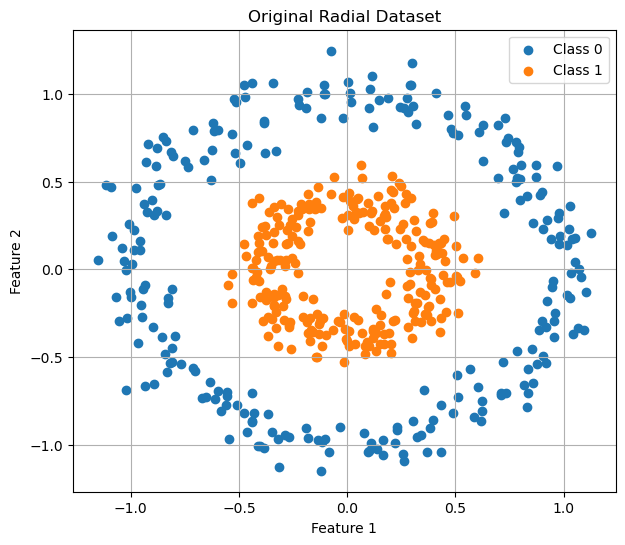


Running Linear Kernel Grid Search...

Running Polynomial Kernel Grid Search...

Running RBF Kernel Grid Search...

BEST HYPERPARAMETERS

Linear Kernel
svm__C: 0.1
Best CV Accuracy: 0.6133

Polynomial Kernel
svm__C: 0.1
svm__degree: 2
svm__gamma: 1
Best CV Accuracy: 1.0

RBF Kernel
svm__C: 0.1
svm__gamma: 1
Best CV Accuracy: 1.0

TEST SET PERFORMANCE


,Kernel,Test Accuracy (%)
0,Linear,56.8
1,Polynomial,100.0
2,RBF,100.0


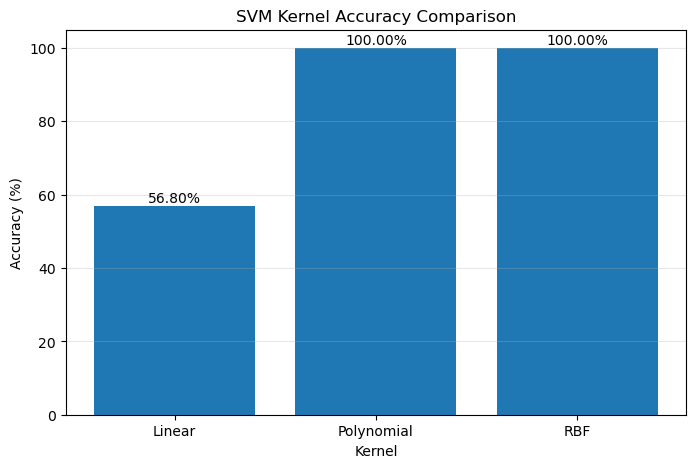

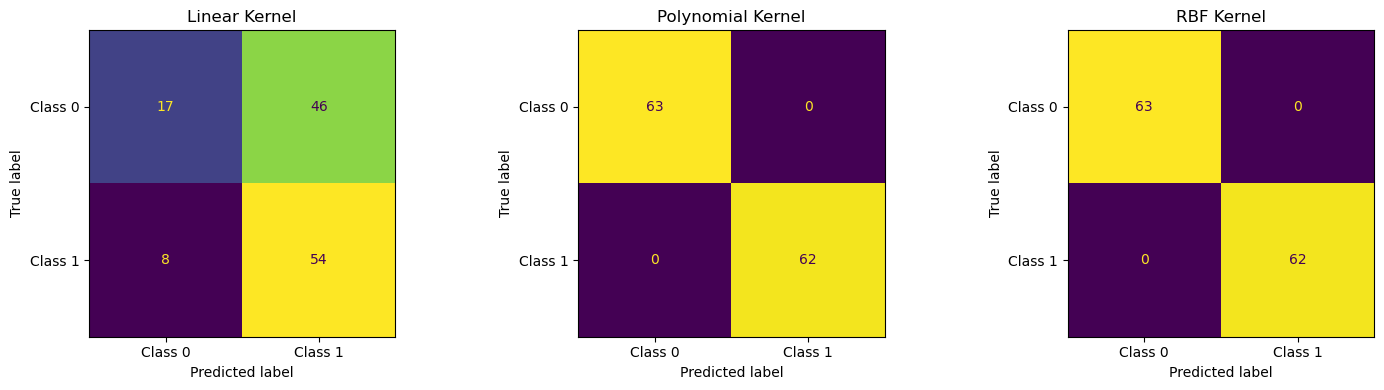

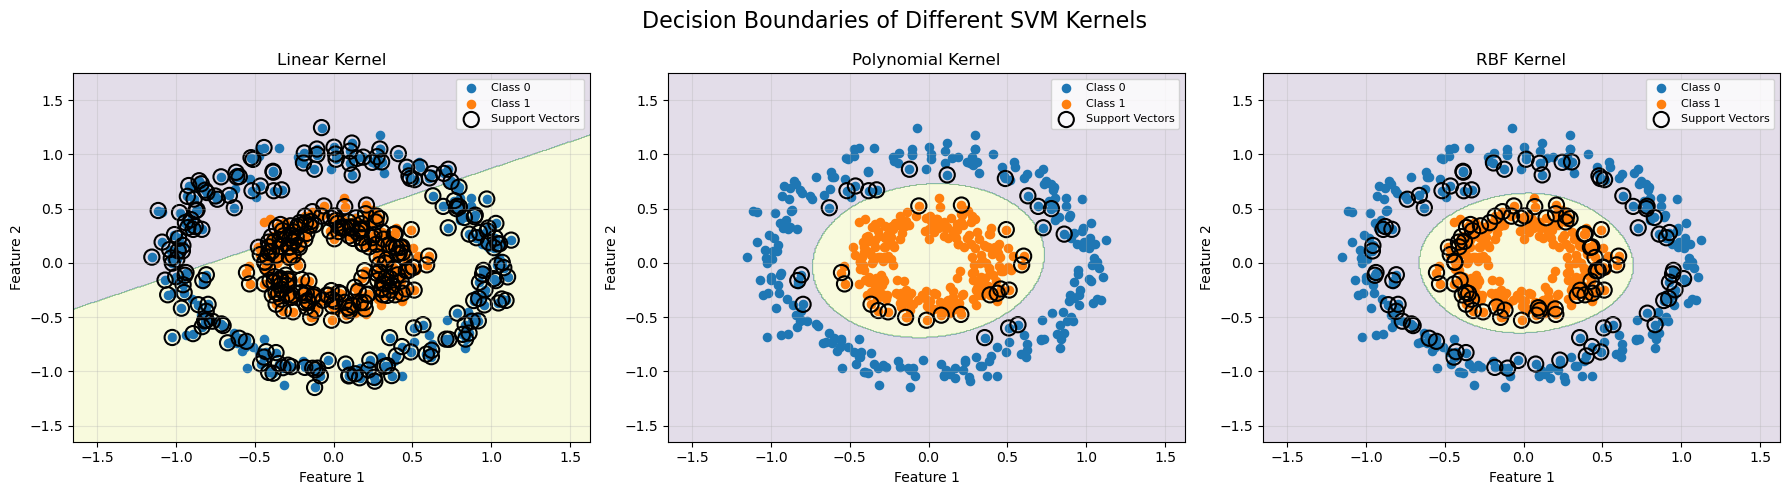


SUPPORT VECTOR COMPARISON


,Kernel,Support Vectors
0,Linear,373
1,Polynomial,37
2,RBF,133


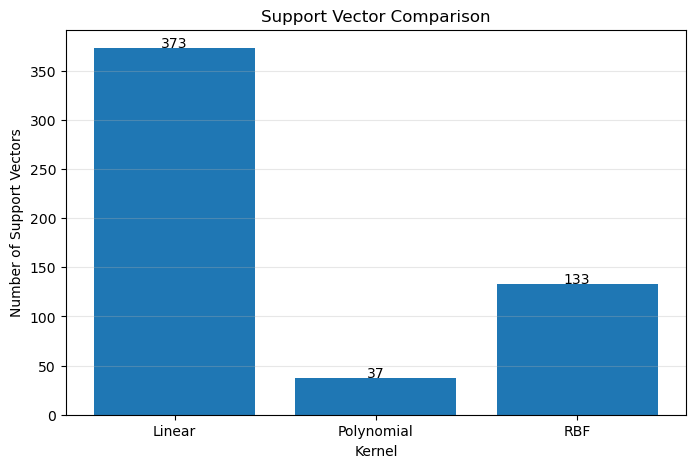

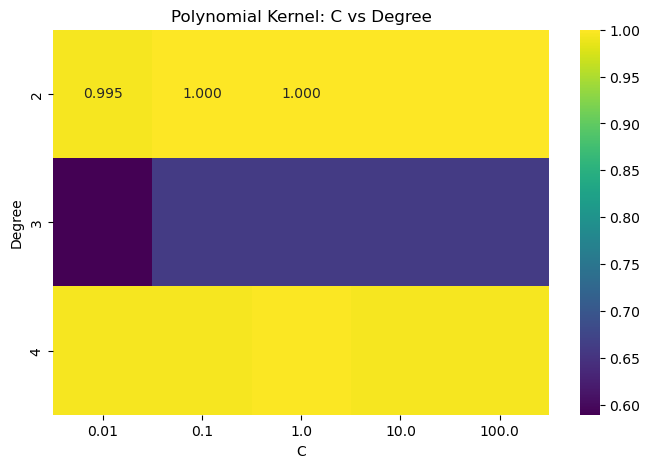

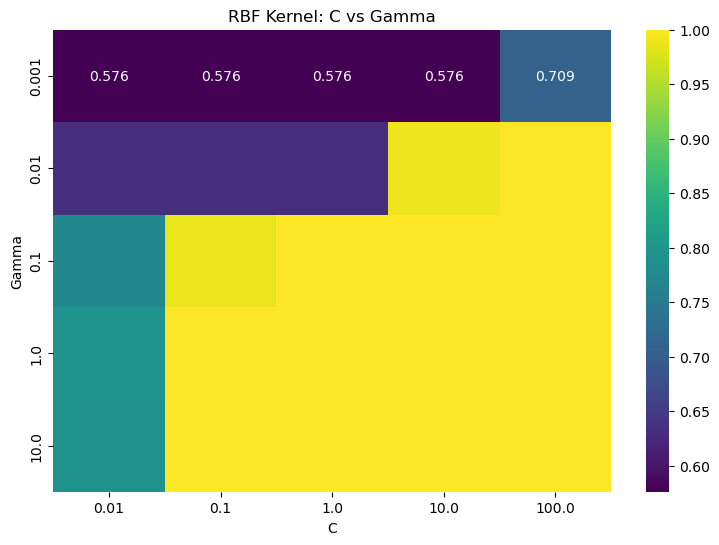

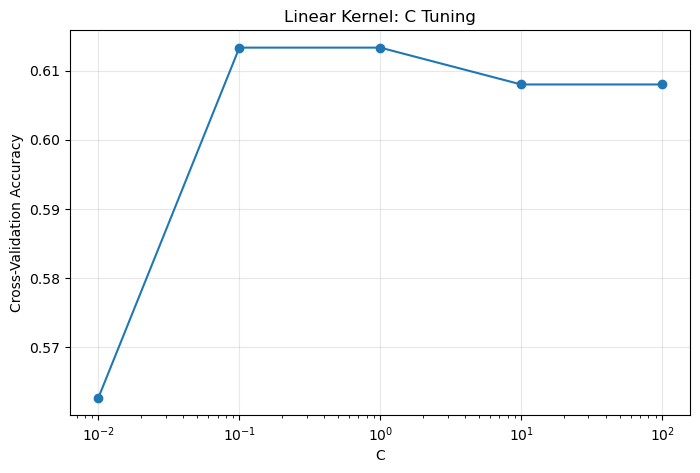


FINAL SVM COMPARISON


,Kernel,Best Parameters,CV Accuracy (%),Test Accuracy (%),Support Vectors
0,Linear,{'svm__C': 0.1},61.33,56.8,373
1,Polynomial,"{'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma'...",100.00,100.0,37
2,RBF,"{'svm__C': 0.1, 'svm__gamma': 1}",100.00,100.0,133


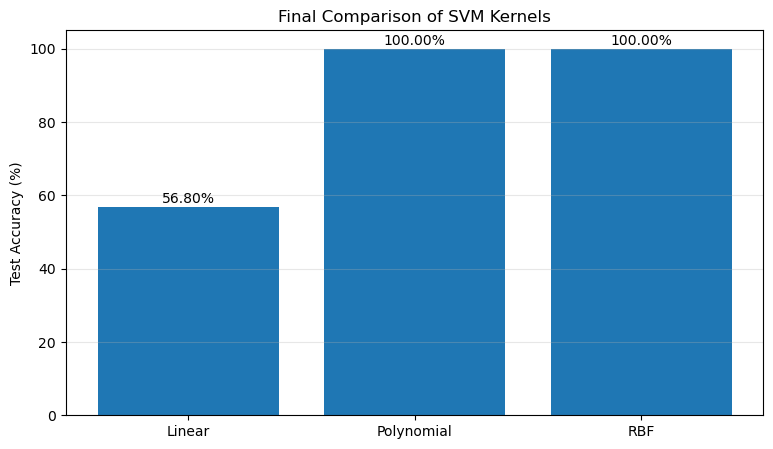

In [ ]:
# ============================================================
# SVM KERNEL COMPARISON
# Linear vs Polynomial vs RBF
# With Hyperparameter Tuning + Accuracy + Visualizations
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import seaborn as sns


# ============================================================
# 1. CREATE RADIAL DATA
# ============================================================

X, y = make_circles(
    n_samples=500,
    factor=0.4,
    noise=0.08,
    random_state=42
)

print("Dataset shape:", X.shape)


# ============================================================
# 2. VISUALIZE ORIGINAL DATA
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Radial Dataset")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. CREATE PIPELINES
#
# Scaling is important for SVM.
# ============================================================

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly"))
])

rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])


# ============================================================
# 5. HYPERPARAMETER GRIDS
# ============================================================

linear_params = {
    "svm__C": [0.01, 0.1, 1, 10, 100]
}

poly_params = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__degree": [2, 3, 4],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

rbf_params = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1, 10]
}


# ============================================================
# 6. GRID SEARCH
# ============================================================

print("\nRunning Linear Kernel Grid Search...")

linear_grid = GridSearchCV(
    linear_pipeline,
    linear_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

linear_grid.fit(X_train, y_train)


print("\nRunning Polynomial Kernel Grid Search...")

poly_grid = GridSearchCV(
    poly_pipeline,
    poly_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

poly_grid.fit(X_train, y_train)


print("\nRunning RBF Kernel Grid Search...")

rbf_grid = GridSearchCV(
    rbf_pipeline,
    rbf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rbf_grid.fit(X_train, y_train)


# ============================================================
# 7. GET BEST MODELS
# ============================================================

models = {
    "Linear": linear_grid.best_estimator_,
    "Polynomial": poly_grid.best_estimator_,
    "RBF": rbf_grid.best_estimator_
}

grids = {
    "Linear": linear_grid,
    "Polynomial": poly_grid,
    "RBF": rbf_grid
}


# ============================================================
# 8. PRINT BEST HYPERPARAMETERS
# ============================================================

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

for name, grid in grids.items():

    print(f"\n{name} Kernel")

    for parameter, value in grid.best_params_.items():
        print(f"{parameter}: {value}")

    print("Best CV Accuracy:", round(grid.best_score_, 4))


# ============================================================
# 9. CALCULATE TEST ACCURACY
# ============================================================

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results.append({
        "Kernel": name,
        "Test Accuracy": accuracy
    })


results_df = pd.DataFrame(results)

results_df["Test Accuracy (%)"] = (
    results_df["Test Accuracy"] * 100
)


print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)

display(
    results_df[
        ["Kernel", "Test Accuracy (%)"]
    ].round(2)
)


# ============================================================
# 10. FINAL ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_df["Kernel"],
    results_df["Test Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Kernel")
plt.title("SVM Kernel Accuracy Comparison")
plt.ylim(0, 105)

for bar, value in zip(
    bars,
    results_df["Test Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# 11. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (name, model) in zip(
    axes,
    models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Class 0", "Class 1"]
    ).plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(f"{name} Kernel")


plt.tight_layout()
plt.show()


# ============================================================
# 12. FUNCTION FOR DECISION BOUNDARY VISUALIZATION
# ============================================================

def plot_decision_boundary(
    model,
    X,
    y,
    title,
    ax
):

    # Create grid
    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            400
        ),
        np.linspace(
            y_min,
            y_max,
            400
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    Z = model.predict(grid)

    Z = Z.reshape(
        xx.shape
    )

    # Decision regions
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.15
    )

    # Plot data
    ax.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0",
        s=35
    )

    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1",
        s=35
    )

    # Support vectors
    scaler = model.named_steps["scaler"]
    svm = model.named_steps["svm"]

    # Convert support vectors back to original space
    support_vectors_original = (
        scaler.inverse_transform(
            svm.support_vectors_
        )
    )

    ax.scatter(
        support_vectors_original[:, 0],
        support_vectors_original[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Support Vectors"
    )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


# ============================================================
# 13. VISUALIZE ALL DECISION BOUNDARIES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (name, model) in zip(
    axes,
    models.items()
):

    plot_decision_boundary(
        model,
        X,
        y,
        f"{name} Kernel",
        ax
    )

plt.suptitle(
    "Decision Boundaries of Different SVM Kernels",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. NUMBER OF SUPPORT VECTORS
# ============================================================

support_vector_results = []

for name, model in models.items():

    svm = model.named_steps["svm"]

    total_support_vectors = (
        len(svm.support_vectors_)
    )

    support_vector_results.append({
        "Kernel": name,
        "Support Vectors": total_support_vectors
    })


support_df = pd.DataFrame(
    support_vector_results
)


print("\n" + "=" * 60)
print("SUPPORT VECTOR COMPARISON")
print("=" * 60)

display(support_df)


# ============================================================
# 15. SUPPORT VECTOR GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    support_df["Kernel"],
    support_df["Support Vectors"]
)

plt.xlabel("Kernel")
plt.ylabel("Number of Support Vectors")
plt.title("Support Vector Comparison")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        str(int(height)),
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 16. POLYNOMIAL KERNEL HYPERPARAMETER HEATMAP
# ============================================================

poly_results = pd.DataFrame(
    poly_grid.cv_results_
)

poly_heatmap = poly_results.pivot_table(
    index="param_svm__degree",
    columns="param_svm__C",
    values="mean_test_score",
    aggfunc="max"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    poly_heatmap,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title(
    "Polynomial Kernel: C vs Degree"
)

plt.xlabel("C")
plt.ylabel("Degree")

plt.show()


# ============================================================
# 17. RBF KERNEL HYPERPARAMETER HEATMAP
# ============================================================

rbf_results = pd.DataFrame(
    rbf_grid.cv_results_
)

rbf_heatmap = rbf_results.pivot_table(
    index="param_svm__gamma",
    columns="param_svm__C",
    values="mean_test_score",
    aggfunc="max"
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    rbf_heatmap,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title(
    "RBF Kernel: C vs Gamma"
)

plt.xlabel("C")
plt.ylabel("Gamma")

plt.show()


# ============================================================
# 18. LINEAR KERNEL C PERFORMANCE
# ============================================================

linear_results = pd.DataFrame(
    linear_grid.cv_results_
)

linear_scores = linear_results[
    [
        "param_svm__C",
        "mean_test_score"
    ]
]

plt.figure(figsize=(8, 5))

plt.plot(
    linear_scores["param_svm__C"],
    linear_scores["mean_test_score"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Linear Kernel: C Tuning")
plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 19. FINAL SUMMARY TABLE
# ============================================================

summary = []

for name, grid in grids.items():

    model = grid.best_estimator_

    test_predictions = model.predict(
        X_test
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    svm = model.named_steps["svm"]

    summary.append({
        "Kernel": name,
        "Best Parameters": grid.best_params_,
        "CV Accuracy": grid.best_score_,
        "Test Accuracy": test_accuracy,
        "Support Vectors": len(
            svm.support_vectors_
        )
    })


summary_df = pd.DataFrame(summary)

summary_df["CV Accuracy (%)"] = (
    summary_df["CV Accuracy"] * 100
)

summary_df["Test Accuracy (%)"] = (
    summary_df["Test Accuracy"] * 100
)


print("\n" + "=" * 80)
print("FINAL SVM COMPARISON")
print("=" * 80)

display(
    summary_df[
        [
            "Kernel",
            "Best Parameters",
            "CV Accuracy (%)",
            "Test Accuracy (%)",
            "Support Vectors"
        ]
    ].round(2)
)


# ============================================================
# 20. FINAL TEST ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    summary_df["Kernel"],
    summary_df["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.title("Final Comparison of SVM Kernels")
plt.ylim(0, 105)

for bar, value in zip(
    bars,
    summary_df["Test Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()
